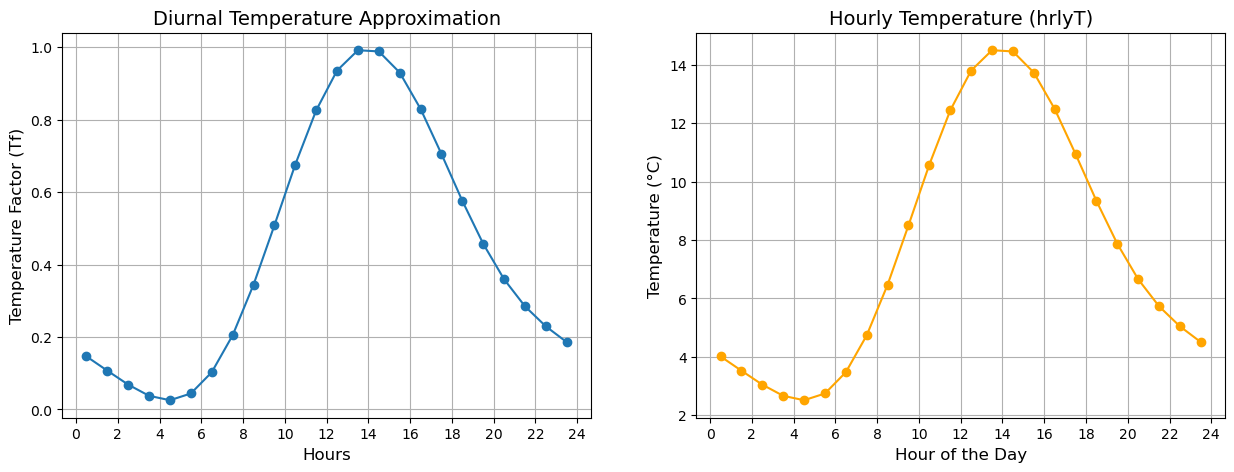

In [1]:
# plot Tf

import numpy as np
import matplotlib.pyplot as plt

# Define the hours and the formula
hrs = np.arange(0.5, 24, 1)
Tx = 14.6
Tm = 8.4
Tn = 2.2

Tf = 0.44 - 0.46 * np.sin((np.pi * hrs) / 12 + 0.9) + 0.11 * np.sin((2 * np.pi * hrs) / 12 + 0.9)
hrlyT = Tx * Tf + Tn * (1 - Tf)

# Plot the function
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(hrs, Tf, marker='o')
plt.title('Diurnal Temperature Approximation', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Temperature Factor (Tf)', fontsize=12)
plt.grid(True)
plt.xticks(np.arange(0, 25, 2))

plt.subplot(1, 2, 2)
plt.plot(hrs, hrlyT, label="Hourly Temperature (hrlyT)", color='orange',marker='o')
plt.title("Hourly Temperature (hrlyT)", fontsize=14)
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(True)
plt.xticks(np.arange(0, 25, 2))

# Display the plot
plt.show()

In [2]:
hrlyT

array([ 4.01482411,  3.52620303,  3.04828011,  2.66547935,  2.51439274,
        2.74486211,  3.47237649,  4.73504817,  6.46751856,  8.49986834,
       10.58309146, 12.43567421, 13.80017097, 14.49590237, 14.45476505,
       13.73141679, 12.48565733, 10.94192864,  9.33662843,  7.86684644,
        6.65343629,  5.72723553,  5.04085847,  4.50153505])

In [118]:
T_base = 1

hourly_DD = np.maximum(hrlyT - T_base, 0)
daily_DD_hourly = np.sum(hourly_DD)/24
print(hourly_DD,daily_DD_hourly)

[ 3.01482411  2.52620303  2.04828011  1.66547935  1.51439274  1.74486211
  2.47237649  3.73504817  5.46751856  7.49986834  9.58309146 11.43567421
 12.80017097 13.49590237 13.45476505 12.73141679 11.48565733  9.94192864
  8.33662843  6.86684644  5.65343629  4.72723553  4.04085847  3.50153505] 6.655999999999999


In [126]:
def calculate_gdd_book(T_max, T_min, thr, upp=None):
    """
    Calculate Growing Degree Days (GDD) with upper and lower thresholds.
    Using method similar to Nathan's from Campbell and Norman, Environmental Biophysics
    Using hourly average, instead of integration.

    Parameters:
        T_max (float): Daily maximum temperature.
        T_min (float): Daily minimum temperature.
        THR (float): Lower threshold temperature.
        UPP (float): Upper threshold temperature.

    Returns:
        float: Calculated GDD.
    """
    # Constants
    hrs = np.arange(0.5, 24, 1)  # Hourly time range (0.5 to 23.5)
    Tf = 0.44 - 0.46 * np.sin((np.pi * hrs) / 12 + 0.9) + 0.11 * np.sin((2 * np.pi * hrs) / 12 + 0.9)

    # Calculate hourly T
    hrlyT = T_max * Tf + T_min * (1 - Tf)

    # Calculate hourly Degree Days
    # return 0 if lower than THR
    hourly_DD = np.maximum(hrlyT - thr, 0)
    
    if upp is not None:
        # return max if higher than UPP
        hourly_DD = np.minimum(hourly_DD, upp - thr)
    
    daily_DD = np.sum(hourly_DD / 24)
    
    
    return daily_DD